In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""
<div style="text-align:center">
  <img src="https://cdn-thumbnails.huggingface.co/social-thumbnails/spaces/Oguzz07/Dog-vs-Cat-CNN.png" width="650">
</div>
"""))

## 🐶🐱 Dogs vs Cats Dataset Extraction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# تحديد مسار المجلد
folder_path = '/content/drive/MyDrive/Dogs vs. Cats'

# عرض الملفات داخل المجلد
files = os.listdir(folder_path)
print(files)

['train.zip', 'test1(1).zip']


### 📦 Unzipping Dogs vs Cats Train and Test Datasets


In [ ]:
# @title
import zipfile

zip_path = '/content/drive/MyDrive/Dogs vs. Cats/train.zip'
extract_path = '/content/drive/MyDrive/Dogs vs. Cats/train'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Train extracted successfully ✅")


Train extracted successfully ✅


In [ ]:
# @title
zip_path = '/content/drive/MyDrive/Dogs vs. Cats/test1(1).zip'
extract_path = '/content/drive/MyDrive/Dogs vs. Cats/test1'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Test extracted successfully ✅")

Test extracted successfully ✅


### 🐾 Visual Analysis of Dogs vs Cats Images

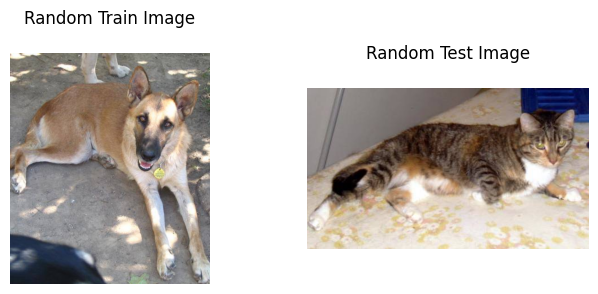

In [ ]:
# @title
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# -----------------------------
# Use existing paths and correct them for nested structure
# -----------------------------
train_path = '/content/drive/MyDrive/Dogs vs. Cats/train/train' # Corrected path for train images
test_path  = '/content/drive/MyDrive/Dogs vs. Cats/test1/test1'  # Corrected path for test images

# -----------------------------
# Get all image files
# -----------------------------
train_images = [f for f in os.listdir(train_path) if f.lower().endswith('.jpg')]
test_images  = [f for f in os.listdir(test_path) if f.lower().endswith('.jpg')]

# -----------------------------
# Pick random images
# -----------------------------
train_img_name = random.choice(train_images)
test_img_name  = random.choice(test_images)

train_img_path = os.path.join(train_path, train_img_name)
test_img_path  = os.path.join(test_path, test_img_name)

train_img = Image.open(train_img_path)
test_img  = Image.open(test_img_path)

# -----------------------------
# Visualize images
# -----------------------------
plt.figure(figsize=(8,3))

# Train image
plt.subplot(1,2,1)
plt.imshow(train_img)
plt.axis("off")
plt.title("Random Train Image\n", fontsize=12)

# Test image
plt.subplot(1,2,2)
plt.imshow(test_img)
plt.axis("off")
plt.title("Random Test Image\n", fontsize=12)

plt.show()

Train images: 25000
Test images : 12500

Cats in train: 12500
Dogs in train: 12500


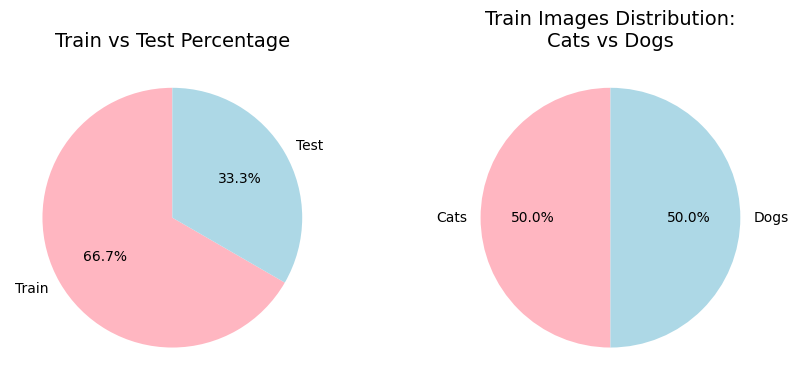

In [ ]:
# @title
import matplotlib.pyplot as plt

# -----------------------------
# Counts
# -----------------------------
train_count = len(train_images)
test_count  = len(test_images)

cat_count = len([f for f in train_images if f.startswith('cat')])
dog_count = len([f for f in train_images if f.startswith('dog')])

# -----------------------------
# Print counts above charts
# -----------------------------
print(f"Train images: {train_count}\nTest images : {test_count}\n")
print(f"Cats in train: {cat_count}\nDogs in train: {dog_count}")

# -----------------------------
# Subplots: Pie charts
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4))  # 1 row, 2 columns

# Pie chart 1: Train vs Test
axes[0].pie([train_count, test_count],
            labels=['Train', 'Test'],
            autopct='%1.1f%%',
            colors=['lightpink','lightblue'],
            startangle=90)
axes[0].set_title("Train vs Test Percentage", fontsize=14)

# Pie chart 2: Cats vs Dogs in Train (title in 2 lines)
axes[1].pie([cat_count, dog_count],
            labels=['Cats', 'Dogs'],
            autopct='%1.1f%%',
            colors=['lightpink','lightblue'],
            startangle=90)
axes[1].set_title("Train Images Distribution:\nCats vs Dogs", fontsize=14)

plt.tight_layout()
plt.show()

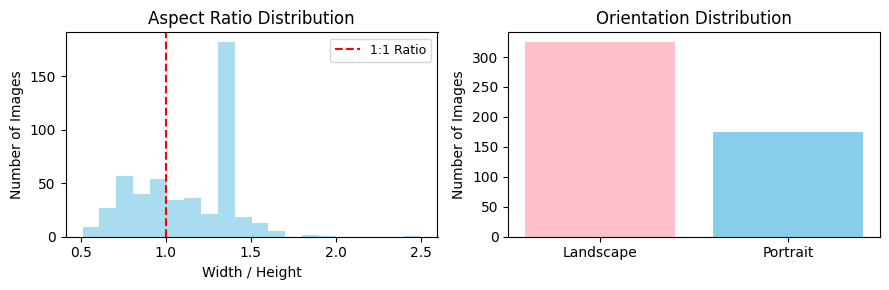

In [ ]:
# @title
from PIL import Image
import os
import matplotlib.pyplot as plt

# -----------------------------
# Sample images
# -----------------------------
sample_images = train_images[:500]

# -----------------------------
# Aspect ratios
# -----------------------------
train_ratios = [Image.open(os.path.join(train_path, f)).width /
                Image.open(os.path.join(train_path, f)).height
                for f in sample_images]

# -----------------------------
# Sizes for orientation
# -----------------------------
sizes = []
for f in sample_images:
    try:
        img = Image.open(os.path.join(train_path, f))
        sizes.append((img.width, img.height))
    except FileNotFoundError:
        print(f"Warning: Image file not found at {os.path.join(train_path, f)}")
    except Exception as e:
        print(f"Error processing image {f}: {e}")

orientation = ['Landscape' if w>h else 'Portrait' for w,h in sizes]

# -----------------------------
# Subplots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(9,3))  # صف واحد، عمودين

# Subplot 1: Aspect Ratio Histogram
axes[0].hist(train_ratios, bins=20, alpha=0.7, color='skyblue')
axes[0].axvline(1, color='red', linestyle='--', label='1:1 Ratio')
axes[0].set_title("Aspect Ratio Distribution", fontsize=12)
axes[0].set_xlabel("Width / Height", fontsize=10)
axes[0].set_ylabel("Number of Images", fontsize=10)
axes[0].legend(fontsize=9)

# Subplot 2: Orientation Bar chart
axes[1].bar(['Landscape', 'Portrait'],
            [orientation.count('Landscape'), orientation.count('Portrait')],
            color=['pink', 'skyblue'])
axes[1].set_title("Orientation Distribution", fontsize=12)
axes[1].set_ylabel("Number of Images", fontsize=10)

plt.tight_layout()
plt.show()

###📂 **Dogs vs Cats – Train / Validation Split (80% / 20%)**

Dogs vs Cats  
│  
└── **train80**  
    ├── **train (80%)**  
    │   ├── **cat** 🐱 ██████████  
    │   └── **dog** 🐶 ██████████  
    │  
    └── **val (20%)**  
        ├── **cat** 🐱 ███  
        └── **dog** 🐶 ███

In [ ]:
# @title
"""import os
import random
import shutil

# ---------------------------
# Paths (مسارات)
train_extract = '/content/drive/MyDrive/Dogs vs. Cats/train/train'
classes = ['cat', 'dog']

# New directories for the split data (مجلدات جديدة للتقسيم)
# These directories will be created to store the 80% training and 20% validation images.
base_train = '/content/drive/MyDrive/Dogs vs. Cats/train80/train'
base_val   = '/content/drive/MyDrive/Dogs vs. Cats/train80/val'

# Create the new directories if they don't exist (إنشاء المجلدات إذا لم تكن موجودة)
# This is done once per class
for cls in classes:
    os.makedirs(os.path.join(base_train, cls), exist_ok=True)
    os.makedirs(os.path.join(base_val, cls), exist_ok=True)

# ---------------------------
# Split images for each Class (تقسيم الصور لكل Class بنسبة 80%-20%)
# ---------------------------
split_ratio = 0.8

for cls in classes:
    cls_images = [f for f in os.listdir(train_extract) if cls in f.lower()]
    random.shuffle(cls_images)

    n_train = int(len(cls_images) * split_ratio)

    # Copy to train set (نسخ للـ train)
    for img in cls_images[:n_train]:
        dest_path = os.path.join(base_train, cls, img)
        # Ensure the destination directory exists immediately before copying
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        shutil.copy(os.path.join(train_extract, img), dest_path)

    # Copy to validation set (نسخ للـ val)
    for img in cls_images[n_train:]:
        dest_path = os.path.join(base_val, cls, img)
        # Ensure the destination directory exists immediately before copying
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        shutil.copy(os.path.join(train_extract, img), dest_path)

# ---------------------------
# Verify counts (التأكد من الأعداد)
# ---------------------------
for cls in classes:
    train_count = len(os.listdir(os.path.join(base_train, cls)))
    val_count   = len(os.listdir(os.path.join(base_val, cls)))
    total_count = train_count + val_count
    print(f"{cls} -> total: {total_count}, train: {train_count}, val: {val_count}")

overall_train = sum(len(os.listdir(os.path.join(base_train, cls))) for cls in classes)
overall_val   = sum(len(os.listdir(os.path.join(base_val, cls))) for cls in classes)
overall_total = overall_train + overall_val
#print("\nOverall counts:")
#print("All images:", overall_total)
#print("Train images:", overall_train)
#print("Validation images:", overall_val)"""


cat -> total: 12500, train: 10000, val: 2500
dog -> total: 12500, train: 10000, val: 2500


In [ ]:
# @title
print("\nOverall counts:")
print("All images:", overall_total)
print("Train images:", overall_train)
print("Validation images:", overall_val)


Overall counts:
All images: 25000
Train images: 20000
Validation images: 5000


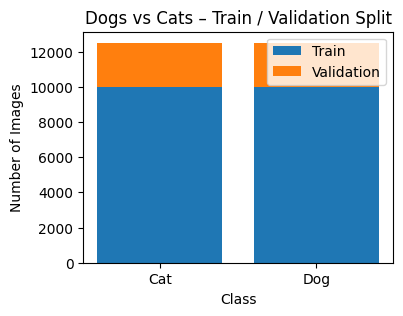

In [ ]:
# @title
import matplotlib.pyplot as plt

# Output counts
classes = ['Cat', 'Dog']
train_counts = [10000, 10000]
val_counts = [2500, 2500]

# Smaller figure size
plt.figure(figsize=(4, 3))  # width=4, height=3 inches

plt.bar(classes, train_counts, label='Train')
plt.bar(classes, val_counts, bottom=train_counts, label='Validation')

plt.title('Dogs vs Cats – Train / Validation Split')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.legend()

plt.show()

### **🖼️Preparing and Augmenting Dogs vs Cats Images for Deep Learning**

In [ ]:
# @title
"""# @title
# title Image Data Generator – Augmentation محسّنة
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------------------------
# Paths
train_dir = '/content/drive/MyDrive/Dogs vs. Cats/train80/train'
val_dir   = '/content/drive/MyDrive/Dogs vs. Cats/train80/val'

# Image size & batch
img_size = (150, 150)   # Resize مناسب لكل الصور
batch_size = 32

# ---------------------------
# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,           # زيادة التدوير لتغطية orientations المختلفة
    width_shift_range=0.15,      # زيادة قليل في shifts
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],  # تعديل الإضاءة لتقليل overfitting
    fill_mode='nearest'
)

# For validation we only rescale
val_datagen = ImageDataGenerator(rescale=1./255)

# ---------------------------
# Flow from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)"""

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


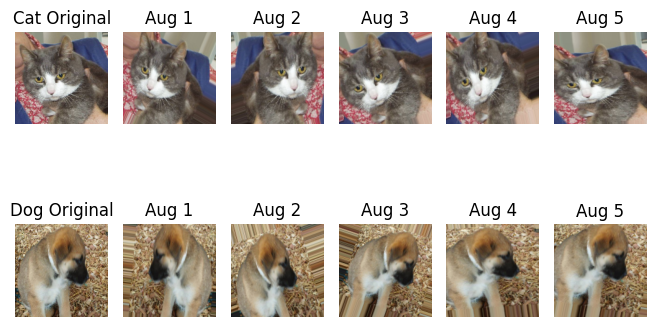

In [ ]:
# @title
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
import os
import random

# ---------------------------
# تعريف ImageDataGenerator
# ---------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ---------------------------
# مسار فولدر Train
# ---------------------------
train_folder = "/content/drive/MyDrive/Dogs vs. Cats/train/train"
all_images = [f for f in os.listdir(train_folder) if f.lower().endswith('.jpg')]

# تصنيف الصور حسب الاسم
cats = [f for f in all_images if 'cat' in f.lower()]
dogs = [f for f in all_images if 'dog' in f.lower()]
classes = {'Cat': cats, 'Dog': dogs}

# ---------------------------
# عرض صورة أصلية + 5 Augmented لكل Class في نفس الـ figure
# ---------------------------
fig = plt.figure(figsize=(12,4))
gs = GridSpec(2, 11, figure=fig)  # 1 عمود للصورة الأصلية + 5 للـ Augmented لكل Class

for row_idx, (cls, images_list) in enumerate(classes.items()):
    # صورة عشوائية
    sample_img_name = random.choice(images_list)
    img_path = os.path.join(train_folder, sample_img_name)

    img = load_img(img_path, target_size=(150,150))
    x = img_to_array(img).reshape((1,) + (150,150,3))

    # Original Image
    plt.subplot(gs[row_idx, 0])
    plt.imshow(np.array(img)/255.0)
    plt.axis("off")
    plt.title(f"{cls} Original")

    # Augmented Images (5 لكل class)
    for i, batch in enumerate(datagen.flow(x, batch_size=1)):
        plt.subplot(gs[row_idx, i+1])
        plt.imshow(batch[0])
        plt.axis("off")
        plt.title(f"Aug {i+1}")
        if i >= 4:  # 5 صور augmented
            break

plt.tight_layout()
plt.show()

### 🚀📊 CNN Model for Dogs vs Cats Classification

In [ ]:
# @title
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Input

# ---------------------------
# 1️⃣ Build CNN Model
# ---------------------------
model = Sequential([
    Input(shape=(150,150,3)),   # ← استخدم Input layer
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

# ---------------------------
# 2️⃣ Compile the Model
# ---------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---------------------------
# 3️⃣ Callbacks
# ---------------------------
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras', # Fixed: Added a filename with .keras extension
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,   # زودنا شوية صبر للتوقف المبكر
    restore_best_weights=True,
    verbose=1
)

# ---------------------------
# 4️⃣ Train the Model
# ---------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,  # زودنا عدد الـ epochs
    callbacks=[checkpoint, early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6215 - loss: 0.6678
Epoch 1: val_accuracy improved from -inf to 0.71720, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1996s 3s/step - accuracy: 0.6215 - loss: 0.6677 - val_accuracy: 0.7172 - val_loss: 0.5645
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7042 - loss: 0.5643
Epoch 2: val_accuracy improved from 0.71720 to 0.75180, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1795s 3s/step - accuracy: 0.7042 - loss: 0.5643 - val_accuracy: 0.7518 - val_loss: 0.5111
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7446 - loss: 0.5206
Epoch 3: val_accuracy improved from 0.75180 to 0.78760, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1807s 3s/step - accuracy: 0.7446 - loss: 0.5206 - val_accuracy: 0.7876 - val_loss: 0.

###📊 Evaluate Trained Model on Train and Validation Data

Train Accuracy: 89.25%
Validation Accuracy: 89.74%


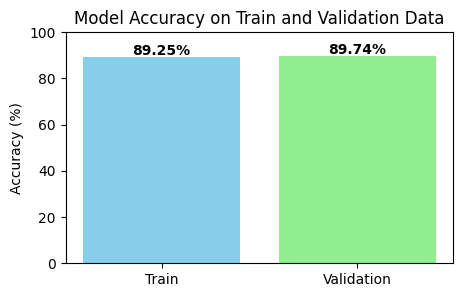

In [ ]:
# @title
"""from tensorflow.keras.models import load_model

# تحميل الموديل
model = load_model('/content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras')

# حساب الدقة والخسارة على بيانات التدريب
train_loss, train_acc = model.evaluate(train_generator)
val_loss, val_acc = model.evaluate(val_generator)
"""
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")



# Prepare data for bar chart
labels = ['Train', 'Validation']
accuracy = [train_acc*100, val_acc*100]
loss = [train_loss, val_loss]

# Accuracy bar chart
plt.figure(figsize=(5,3))
plt.bar(labels, accuracy, color=['skyblue','lightgreen'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy on Train and Validation Data')
for i, v in enumerate(accuracy):
    plt.text(i, v+1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

###🧪 Dogs vs Cats – Confusion Matrix & Report

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step


<Figure size 500x400 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


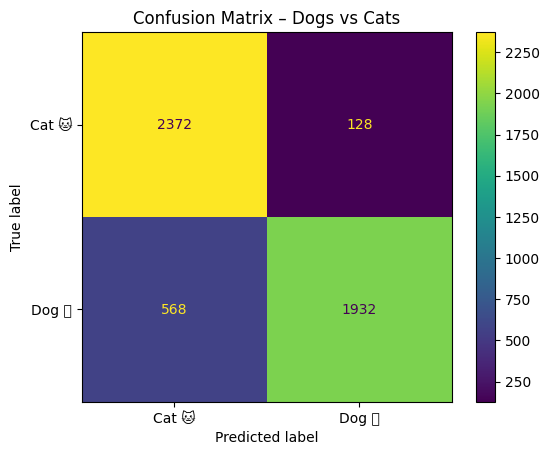

In [ ]:
# @title
"""val_generator = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/Dogs vs. Cats/train80/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # 👈 مهم جدًا
)
"""


model = load_model('/content/drive/MyDrive/Dogs vs. Cats/train/best_model.keras')

val_generator.reset()

y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Cat 🐱', 'Dog 🐶']
)

plt.figure(figsize=(5,4))
disp.plot()
plt.title('Confusion Matrix – Dogs vs Cats')
plt.show()

In [ ]:
# @title
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Cat 🐱', 'Dog 🐶']
))

              precision    recall  f1-score   support

       Cat 🐱       0.81      0.95      0.87      2500
       Dog 🐶       0.94      0.77      0.85      2500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



### 📝 Dogs vs Cats – Confusion Matrix (After Adjustment)

=== Classification Report (After Adjustment) ===
              precision    recall  f1-score   support

       Cat 🐱       0.86      0.92      0.89      2500
       Dog 🐶       0.91      0.85      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



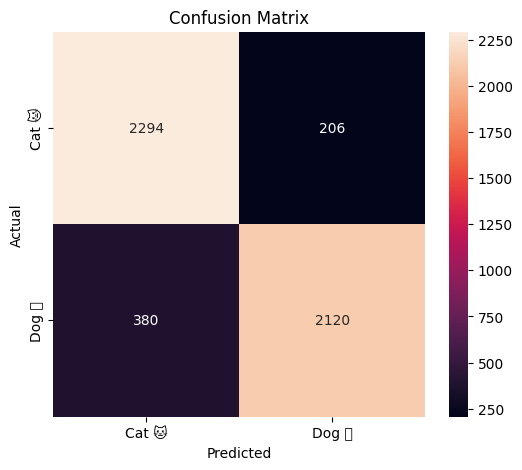

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# 1️⃣: التوقعات الأصلية من النموذج (probabilities)
# Use y_pred_prob from the previous cell which contains probabilities for dogs (class 1)
preds_probs = y_pred_prob # Assign existing variable y_pred_prob to preds_probs
# -------------------------------

# -------------------------------
# 2️⃣: تعديل العتبة (Threshold Adjustment)
# نجرب threshold أقل للكلاب عشان نزيد عدد التوقعات الصحيحة لها
threshold = 0.4  # أقل من 0.5 التقليدي
# Use preds_probs[:,0] to access the probabilities, as y_pred_prob is (num_samples, 1)
preds_final = np.where(preds_probs[:,0] > threshold, 1, 0)  # 0=Cat, 1=Dog

# -------------------------------
# 3️⃣: طباعة تقرير التصنيف
print("=== Classification Report (After Adjustment) ===")
# Use y_true for the actual labels
print(classification_report(y_true, preds_final, target_names=['Cat 🐱', 'Dog 🐶']))

# -------------------------------
# 4️⃣: مصفوفة الالتباس
# Use y_true for the actual labels
cm = confusion_matrix(y_true, preds_final)
labels = ['Cat 🐱', 'Dog 🐶']

# -------------------------------
# 5️⃣: رسم Confusion Matrix باستخدام Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# @title
from IPython.display import display, HTML

display(HTML("""
<div style="text-align:center">
  <img src="https://miro.medium.com/v2/resize:fit:1200/1*LdB0MQG6mR7vvtPeE13avg.png" width="600">
</div>
"""))

### 💻 VGG16 Transfer Learning Model – Dogs vs Cats

In [ ]:
# @title
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
# @title
"""# @title
# ===============================
# 🐶🐱 Dogs vs Cats - VGG16 Transfer Learning (All-in-One)
# ===============================

# ===== 1. Imports =====

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ===== 2. Paths & Parameters =====
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = '/content/drive/MyDrive/Dogs vs. Cats/train80/train'
val_dir   = '/content/drive/MyDrive/Dogs vs. Cats/train80/val'

# ===== 3. Data Generators =====
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ===== 5. Load VGG16 Base Model =====
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# ===== 6. Build Custom Head =====
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

# ===== 7. Compile (Transfer Learning Phase) =====
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== 8. Callbacks =====
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Dogs vs. Cats/train/vgg16_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ===== 9. Train (Frozen VGG16) =====
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

# ===== 10. Fine Tuning (Unfreeze Last Layers) =====
for layer in base_model.layers[-4:]:
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== 11. Fine Tuning Training =====
history_vgg_fine = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)"""

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.6525 - loss: 0.6181
Epoch 1: val_accuracy improved from -inf to 0.86820, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/vgg16_best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2086s 3s/step - accuracy: 0.6526 - loss: 0.6180 - val_accuracy: 0.8682 - val_loss: 0.3832
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.8383 - loss: 0.4025
Epoch 2: val_accuracy improved from 0.86820 to 0.88680, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/vgg16_best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 357s 572ms/step - accuracy: 0.8383 - loss: 0.4024 - val_accuracy: 0.8868 - val_loss: 0.2972
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8692 - loss: 0.3269
Epoch 3: val_accuracy improved from 0.88680 to 0.89920, saving model to /content/drive/MyDrive/Dogs vs. Cats/train/vgg16_best_model.keras


In [ ]:
# @title
# دقة التدريب و الـ validation بعد Frozen VGG16
train_acc_frozen = history_vgg.history['accuracy'][-1]
val_acc_frozen   = history_vgg.history['val_accuracy'][-1]

print(f"✅ Frozen Training Accuracy: {train_acc_frozen*100:.2f}%")
print(f"✅ Frozen Training Validation Accuracy: {val_acc_frozen*100:.2f}%")

✅ Frozen Training Accuracy: 90.50%
✅ Frozen Training Validation Accuracy: 91.94%


In [ ]:
# @title
# دقة التدريب و الـ validation بعد Fine-tuning
train_acc_finetune = history_vgg_fine.history['accuracy'][-1]
val_acc_finetune   = history_vgg_fine.history['val_accuracy'][-1]

print(f"✅ Fine-Tuning Accuracy: {train_acc_finetune*100:.2f}%")
print(f"✅ Fine-Tuning Validation Accuracy: {val_acc_finetune*100:.2f}%")

✅ Fine-Tuning Accuracy: 97.22%
✅ Fine-Tuning Validation Accuracy: 96.42%


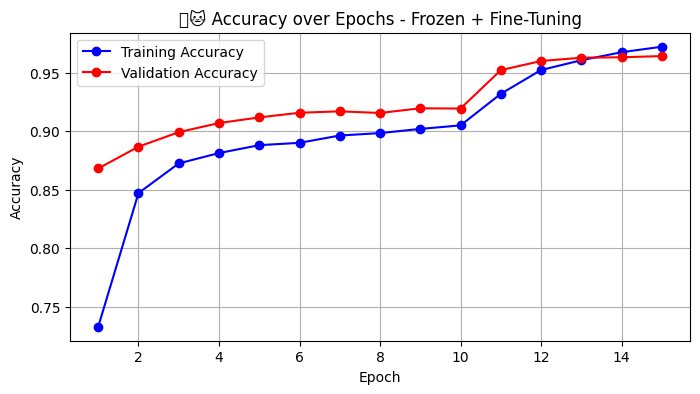

In [ ]:
# @title
import matplotlib.pyplot as plt

# ===== تجميع كل الـ accuracy و val_accuracy =====
train_acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
val_acc   = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']

# ===== عدد الـ epochs =====
epochs = range(1, len(train_acc)+1)

# ===== رسم الدقة =====
plt.figure(figsize=(8,4))
plt.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('🐶🐱 Accuracy over Epochs - Frozen + Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

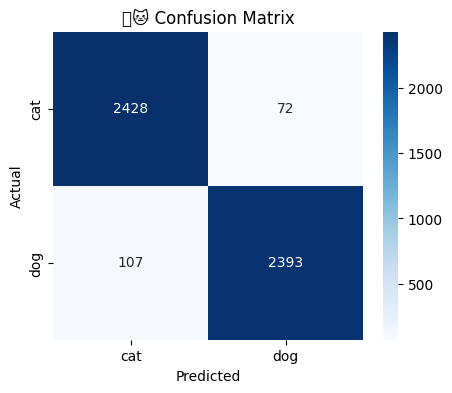

In [ ]:
# @title
# ===== 1. Imports =====
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ===== 2. Predict on Validation Set =====
val_generator.reset()  # مهم عشان predictions تمشي بالترتيب
y_pred_prob = vgg_model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int)  # binary classification

# ===== 3. True labels =====
y_true = val_generator.classes

# ===== 4. Confusion Matrix =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('🐶🐱 Confusion Matrix')
plt.show()

In [ ]:
# @title
# ===== 5. Classification Report =====
report = classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys())
print("📋 Classification Report:\n")
print(report)

📋 Classification Report:

              precision    recall  f1-score   support

         cat       0.96      0.97      0.96      2500
         dog       0.97      0.96      0.96      2500

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000

